# Image Captioning System
**Project:** 2022

A compact encoder–decoder demonstration combining computer vision and NLP. The encoder converts image pixels into a visual representation and an LSTM decoder generates a short caption.

For offline reproducibility, the notebook creates simple synthetic images with known captions. The architecture is the same encoder–decoder pattern used for larger captioning datasets.

In [ ]:
import numpy as np, matplotlib.pyplot as plt, random, torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
np.random.seed(42); random.seed(42); torch.manual_seed(42)
device="cuda" if torch.cuda.is_available() else "cpu"
print("Device:",device)

Device: cpu


In [ ]:
# Synthetic image-caption dataset
vocab=["<pad>","<bos>","<eos>","red","green","blue","circle","square","triangle","object"]
stoi={w:i for i,w in enumerate(vocab)}; itos={i:w for w,i in stoi.items()}

def make_img(shape,color):
    im=Image.new("RGB",(64,64),(245,245,245)); d=ImageDraw.Draw(im)
    c={"red":(220,50,50),"green":(40,160,80),"blue":(50,100,210)}[color]
    if shape=="circle": d.ellipse((16,16,48,48),fill=c)
    elif shape=="square": d.rectangle((16,16,48,48),fill=c)
    else: d.polygon([(32,12),(50,48),(14,48)],fill=c)
    return np.array(im,dtype=np.float32)/255

samples=[]
for shape in ["circle","square","triangle"]:
    for color in ["red","green","blue"]:
        for _ in range(80):
            samples.append((make_img(shape,color),[stoi["<bos>"],stoi[color],stoi[shape],stoi["<eos>"]]))
random.shuffle(samples)
print("Training examples:",len(samples))

Training examples: 720


In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.AdaptiveAvgPool2d(1)
        )
        self.fc=nn.Linear(64,64)
    def forward(self,x): return self.fc(self.net(x).flatten(1))

class Decoder(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        self.emb=nn.Embedding(vocab_size,32)
        self.lstm=nn.LSTM(32+64,64,batch_first=True)
        self.out=nn.Linear(64,vocab_size)
    def forward(self,feat,tokens):
        e=self.emb(tokens)
        f=feat.unsqueeze(1).expand(-1,tokens.size(1),-1)
        h,_=self.lstm(torch.cat([e,f],2))
        return self.out(h)

enc,dec=Encoder().to(device),Decoder(len(vocab)).to(device)
opt=torch.optim.Adam(list(enc.parameters())+list(dec.parameters()),lr=2e-3)
loss_fn=nn.CrossEntropyLoss(ignore_index=stoi["<pad>"])

for epoch in range(12):
    random.shuffle(samples); total=0
    for i in range(0,len(samples),32):
        batch=samples[i:i+32]
        x=torch.tensor(np.stack([a[0].transpose(2,0,1) for a in batch]),dtype=torch.float32).to(device)
        seq=torch.tensor([a[1] for a in batch],dtype=torch.long).to(device)
        feat=enc(x)
        logits=dec(feat,seq[:,:-1])
        loss=loss_fn(logits.reshape(-1,len(vocab)),seq[:,1:].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step(); total+=loss.item()
    if epoch in [0,3,7,11]:
        print(f"Epoch {epoch+1:02d}/12  loss={total/(len(samples)/32):.4f}")

Epoch 01/12  loss=1.6735


Epoch 04/12  loss=0.7679


Epoch 08/12  loss=0.4971


Epoch 12/12  loss=0.3090


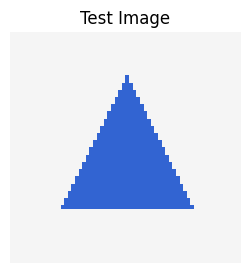

Generated caption: blue triangle


In [ ]:
def caption(img):
    x=torch.tensor(img.transpose(2,0,1)[None],dtype=torch.float32).to(device)
    feat=enc(x)
    tokens=[stoi["<bos>"]]
    for _ in range(3):
        inp=torch.tensor([tokens],dtype=torch.long).to(device)
        logits=dec(feat,inp)[:,-1]
        nxt=int(logits.argmax(1))
        tokens.append(nxt)
        if nxt==stoi["<eos>"]: break
    return " ".join(itos[t] for t in tokens[1:] if t not in [stoi["<eos>"],stoi["<pad>"]])

test_img=make_img("triangle","blue")
plt.figure(figsize=(3,3)); plt.imshow(test_img); plt.axis("off"); plt.title("Test Image"); plt.show()
print("Generated caption:",caption(test_img))